In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 100


In [3]:
df = pd.read_csv('test.csv')

print("Shape:", df.shape)
print("\n── First 5 rows ──")
df.head()

Shape: (14900, 24)

── First 5 rows ──


,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,52685,36,Male,13,Healthcare,8029,Excellent,High,Average,1,...,1,Mid,Large,22,No,No,No,Poor,Medium,Stayed
1,30585,35,Male,7,Education,4563,Good,High,Average,1,...,4,Entry,Medium,27,No,No,No,Good,High,Left
2,54656,50,Male,7,Education,5583,Fair,High,Average,3,...,2,Senior,Medium,76,No,No,Yes,Good,Low,Stayed
3,33442,58,Male,44,Media,5525,Fair,Very High,High,0,...,4,Entry,Medium,96,No,No,No,Poor,Low,Left
4,15667,39,Male,24,Education,4604,Good,High,Average,0,...,6,Mid,Large,45,Yes,No,No,Good,High,Stayed


In [4]:
print("── Column Info ──")
df.info()

print("\n── Numeric Summary ──")
df.describe().round(2)

── Column Info ──
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14900 entries, 0 to 14899
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Employee ID               14900 non-null  int64 
 1   Age                       14900 non-null  int64 
 2   Gender                    14900 non-null  object
 3   Years at Company          14900 non-null  int64 
 4   Job Role                  14900 non-null  object
 5   Monthly Income            14900 non-null  int64 
 6   Work-Life Balance         14900 non-null  object
 7   Job Satisfaction          14900 non-null  object
 8   Performance Rating        14900 non-null  object
 9   Number of Promotions      14900 non-null  int64 
 10  Overtime                  14900 non-null  object
 11  Distance from Home        14900 non-null  int64 
 12  Education Level           14900 non-null  object
 13  Marital Status            14900 non-null  object
 14  Numb

,Employee ID,Age,Years at Company,Monthly Income,Number of Promotions,Distance from Home,Number of Dependents,Company Tenure
count,14900.00,14900.00,14900.00,14900.00,14900.00,14900.00,14900.00,14900.00
mean,37339.02,38.39,15.59,7287.31,0.83,49.93,1.66,55.60
std,21453.13,12.10,11.13,2156.74,1.00,28.70,1.55,25.35
min,5.00,18.00,1.00,1226.00,0.00,1.00,0.00,2.00
25%,18825.50,28.00,7.00,5633.75,0.00,25.00,0.00,36.00
50%,37433.00,38.00,13.00,7332.00,1.00,50.00,1.00,56.00
75%,55857.50,49.00,23.00,8852.00,2.00,75.00,3.00,75.00
max,74471.00,59.00,51.00,15063.00,4.00,99.00,6.00,127.00


In [5]:
# Data Cleaning 

print("Missing values:\n", df.isnull().sum())

# 2. Duplicates
print("\nDuplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()

# 3. Drop Employee ID (not useful for analysis)
df = df.drop(columns=['Employee ID'])

# 4. Strip whitespace from all string columns
str_cols = df.select_dtypes(include='object').columns
df[str_cols] = df[str_cols].apply(lambda x: x.str.strip())

print("\nCleaning done. Shape:", df.shape)
df.head(3)

Missing values:
 Employee ID                 0
Age                         0
Gender                      0
Years at Company            0
Job Role                    0
Monthly Income              0
Work-Life Balance           0
Job Satisfaction            0
Performance Rating          0
Number of Promotions        0
Overtime                    0
Distance from Home          0
Education Level             0
Marital Status              0
Number of Dependents        0
Job Level                   0
Company Size                0
Company Tenure              0
Remote Work                 0
Leadership Opportunities    0
Innovation Opportunities    0
Company Reputation          0
Employee Recognition        0
Attrition                   0
dtype: int64

Duplicate rows: 0

Cleaning done. Shape: (14900, 23)


,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,Overtime,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,36,Male,13,Healthcare,8029,Excellent,High,Average,1,Yes,...,1,Mid,Large,22,No,No,No,Poor,Medium,Stayed
1,35,Male,7,Education,4563,Good,High,Average,1,Yes,...,4,Entry,Medium,27,No,No,No,Good,High,Left
2,50,Male,7,Education,5583,Fair,High,Average,3,Yes,...,2,Senior,Medium,76,No,No,Yes,Good,Low,Stayed


In [6]:
# Salary Group
df['Salary Group'] = pd.cut(
    df['Monthly Income'],
    bins=[0, 4000, 8000, 12000, 99999],
    labels=['Low', 'Medium', 'High', 'Very High']
)

# Experience Group
df['Experience Group'] = pd.cut(
    df['Years at Company'],
    bins=[0, 2, 5, 10, 99],
    labels=['0-2 yrs', '3-5 yrs', '6-10 yrs', '10+ yrs']
)

# Age Group
df['Age Group'] = pd.cut(
    df['Age'],
    bins=[17, 25, 35, 45, 60],
    labels=['18-25', '26-35', '36-45', '46+']
)

# Binary target: Left = 1, Stayed = 0
df['Attrition Flag'] = (df['Attrition'] == 'Left').astype(int)

print("New features added:", ['Salary Group', 'Experience Group', 'Age Group', 'Attrition Flag'])
df[['Monthly Income', 'Salary Group', 'Years at Company', 'Experience Group', 'Attrition Flag']].head(5)

New features added: ['Salary Group', 'Experience Group', 'Age Group', 'Attrition Flag']


,Monthly Income,Salary Group,Years at Company,Experience Group,Attrition Flag
0,8029,High,13,10+ yrs,0
1,4563,Medium,7,6-10 yrs,1
2,5583,Medium,7,6-10 yrs,0
3,5525,Medium,44,10+ yrs,1
4,4604,Medium,24,10+ yrs,0


Attrition Count:
 Attrition
Stayed    7868
Left      7032
Name: count, dtype: int64

Attrition %:
 Attrition
Stayed    52.8
Left      47.2
Name: proportion, dtype: float64


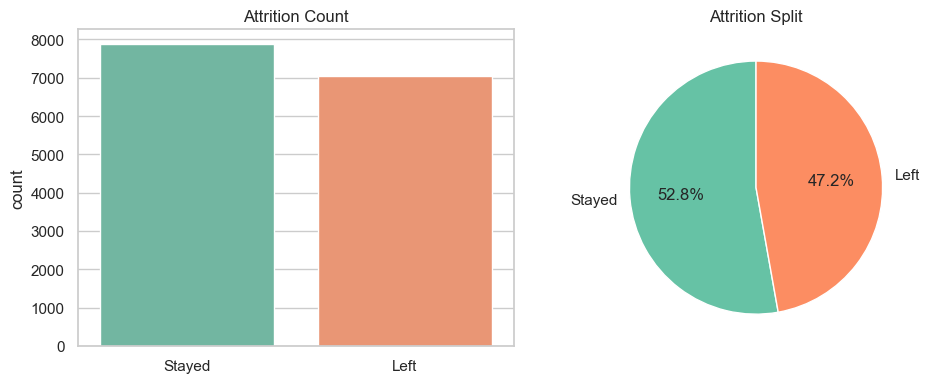

In [7]:
# ── Cell 6 · Overall Attrition Rate ───────────────────

attrition_counts = df['Attrition'].value_counts()
attrition_pct = df['Attrition'].value_counts(normalize=True) * 100

print("Attrition Count:\n", attrition_counts)
print("\nAttrition %:\n", attrition_pct.round(1))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Count plot
sns.countplot(data=df, x='Attrition', palette='Set2', ax=axes[0])
axes[0].set_title('Attrition Count')
axes[0].set_xlabel('')

# Pie chart
axes[1].pie(attrition_counts, labels=attrition_counts.index,
        autopct='%1.1f%%', colors=['#66c2a5', '#fc8d62'], startangle=90)
axes[1].set_title('Attrition Split')

plt.tight_layout()
plt.show()

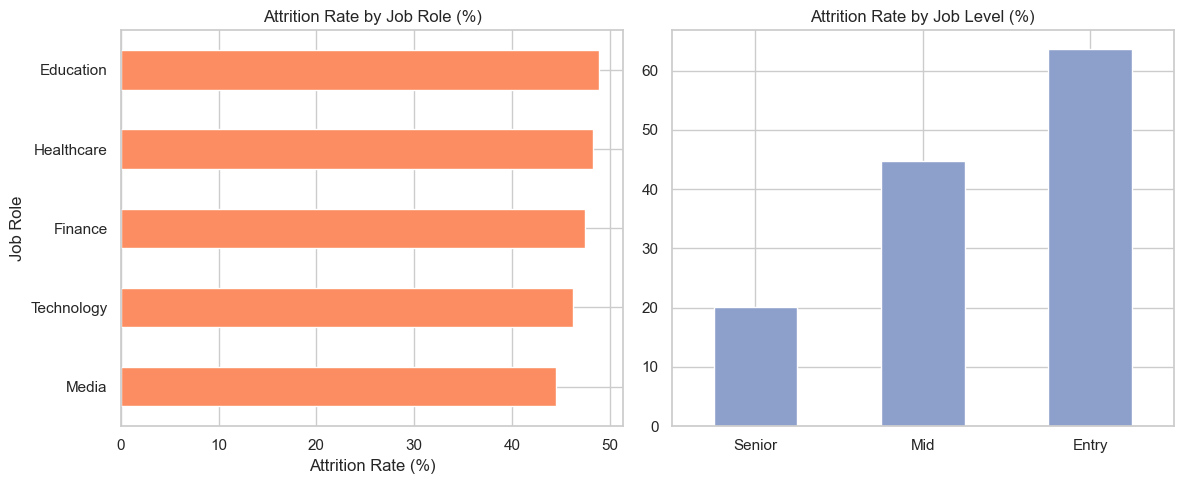

In [8]:
# ── Cell 7 · Attrition by Job Role & Job Level ────────

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# By Job Role
role_attr = df.groupby('Job Role')['Attrition Flag'].mean() * 100
role_attr.sort_values().plot(kind='barh', ax=axes[0], color='#fc8d62')
axes[0].set_title('Attrition Rate by Job Role (%)')
axes[0].set_xlabel('Attrition Rate (%)')

# By Job Level
level_attr = df.groupby('Job Level')['Attrition Flag'].mean() * 100
level_attr.sort_values().plot(kind='bar', ax=axes[1], color='#8da0cb')
axes[1].set_title('Attrition Rate by Job Level (%)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

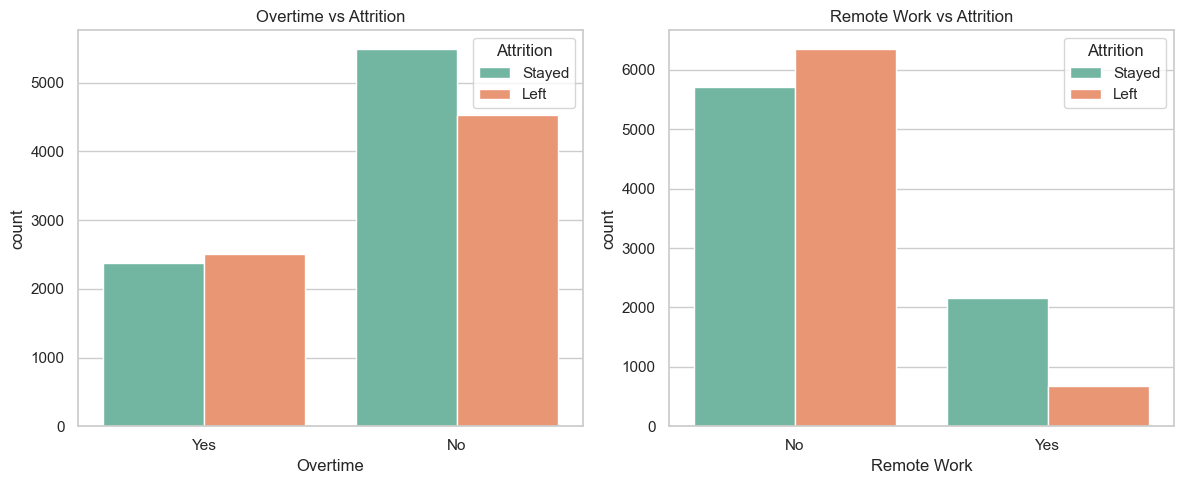

In [9]:
# ── Cell 8 · Overtime & Remote Work vs Attrition ──────

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Overtime
sns.countplot(data=df, x='Overtime', hue='Attrition',
             palette='Set2', ax=axes[0])
axes[0].set_title('Overtime vs Attrition')
axes[0].set_xlabel('Overtime')

# Remote Work
sns.countplot(data=df, x='Remote Work', hue='Attrition',
             palette='Set2', ax=axes[1])
axes[1].set_title('Remote Work vs Attrition')
axes[1].set_xlabel('Remote Work')

plt.tight_layout()
plt.show()

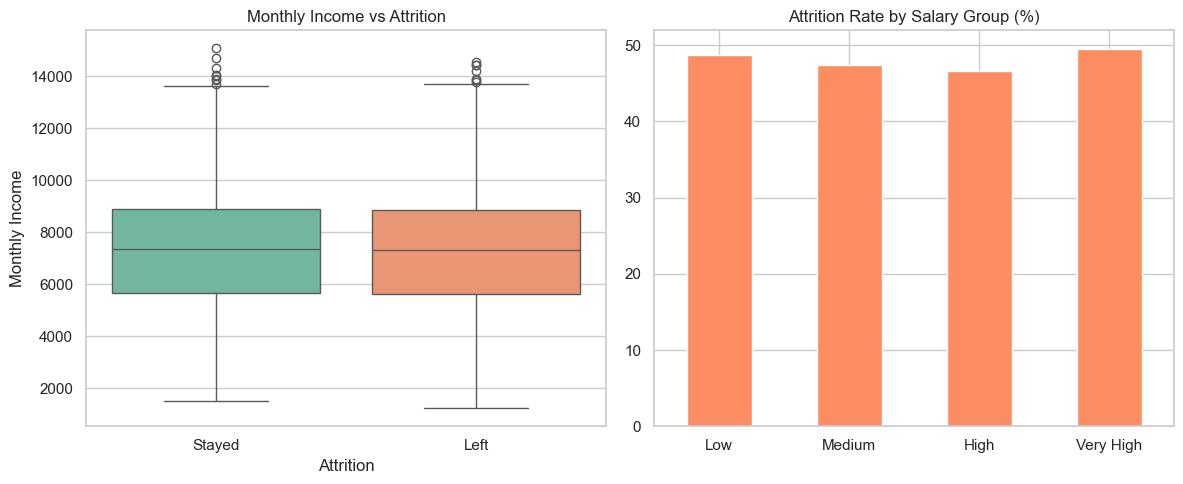

In [10]:
# ── Cell 9 · Monthly Income vs Attrition ──────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Box plot
sns.boxplot(data=df, x='Attrition', y='Monthly Income',
            palette='Set2', ax=axes[0])
axes[0].set_title('Monthly Income vs Attrition')

# Attrition rate by Salary Group
sal_attr = df.groupby('Salary Group', observed=True)['Attrition Flag'].mean() * 100
sal_attr.plot(kind='bar', ax=axes[1], color='#fc8d62', edgecolor='white')
axes[1].set_title('Attrition Rate by Salary Group (%)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

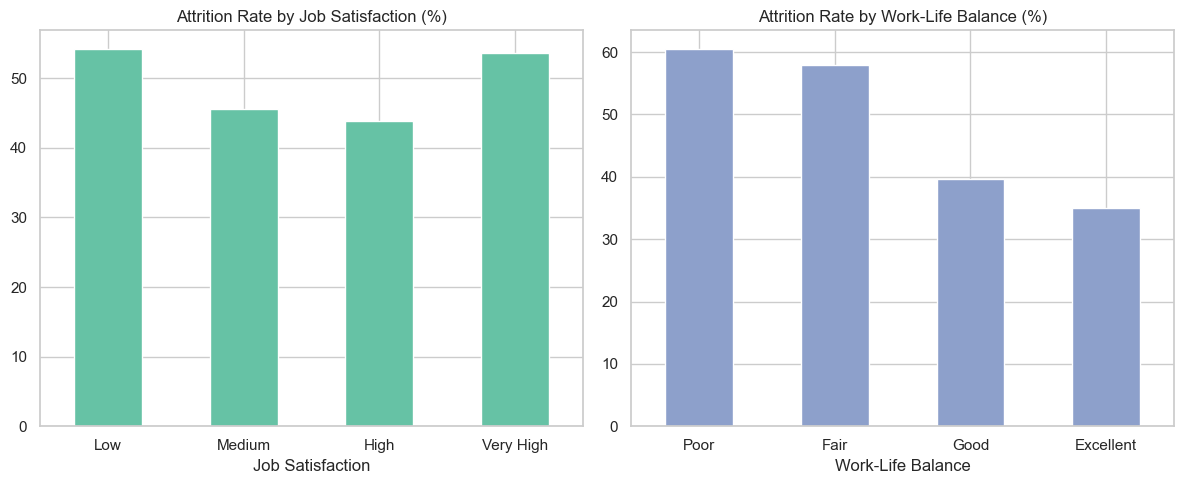

In [11]:
# ── Cell 10 · Satisfaction vs Attrition ───────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Job Satisfaction
sat_order = ['Low', 'Medium', 'High', 'Very High']
sat_attr = df.groupby('Job Satisfaction')['Attrition Flag'].mean() * 100
sat_attr.reindex(sat_order).plot(kind='bar', ax=axes[0], color='#66c2a5')
axes[0].set_title('Attrition Rate by Job Satisfaction (%)')
axes[0].tick_params(axis='x', rotation=0)

# Work-Life Balance
wlb_order = ['Poor', 'Fair', 'Good', 'Excellent']
wlb_attr = df.groupby('Work-Life Balance')['Attrition Flag'].mean() * 100
wlb_attr.reindex(wlb_order).plot(kind='bar', ax=axes[1], color='#8da0cb')
axes[1].set_title('Attrition Rate by Work-Life Balance (%)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

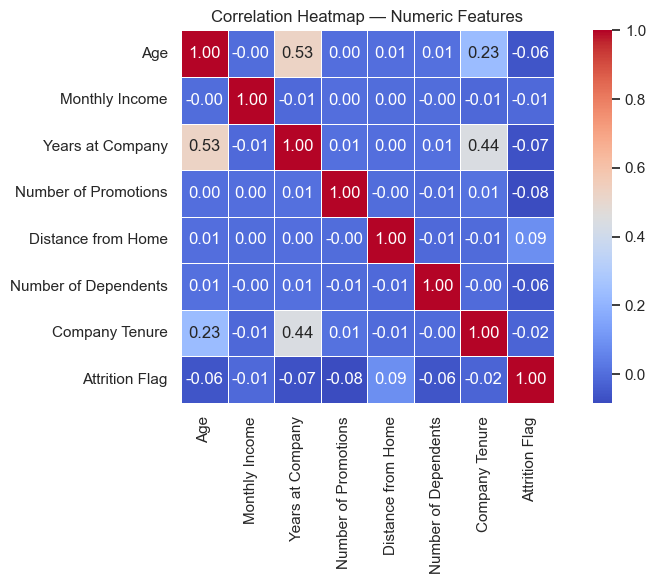


Top correlations with Attrition Flag:
Number of Promotions   -0.083544
Years at Company       -0.067415
Number of Dependents   -0.059540
Age                    -0.058488
Company Tenure         -0.023702
Monthly Income         -0.007973
Distance from Home      0.086942
Name: Attrition Flag, dtype: float64


In [12]:
# ── Cell 11 · Correlation Heatmap ─────────────────────

num_cols = ['Age', 'Monthly Income', 'Years at Company',
            'Number of Promotions', 'Distance from Home',
            'Number of Dependents', 'Company Tenure', 'Attrition Flag']

corr = df[num_cols].corr()

plt.figure(figsize=(9, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap — Numeric Features')
plt.tight_layout()
plt.show()

# Top correlations with Attrition
print("\nTop correlations with Attrition Flag:")
print(corr['Attrition Flag'].drop('Attrition Flag').sort_values())

Attrition Rate % by Job Role × Overtime:

Overtime      No   Yes
Job Role              
Education   47.1  52.7
Finance     46.1  50.3
Healthcare  45.7  53.8
Media       42.6  48.5
Technology  44.3  50.2


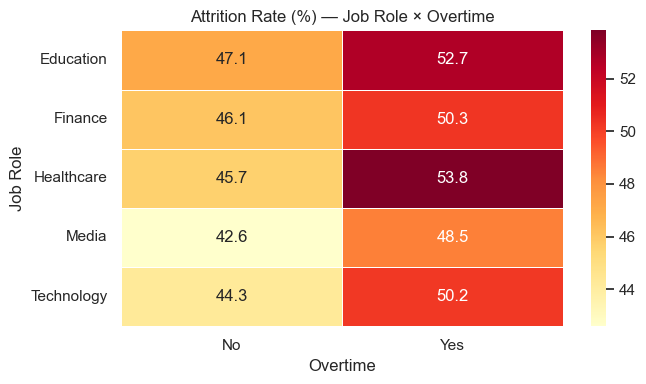

In [13]:
# ── Cell 12 · Group Analysis with Pivot Table ─────────

# Attrition rate by Job Role × Overtime
pivot = df.pivot_table(
    values='Attrition Flag',
    index='Job Role',
    columns='Overtime',
    aggfunc='mean'
) * 100

print("Attrition Rate % by Job Role × Overtime:\n")
print(pivot.round(1))

# Visualize as heatmap
plt.figure(figsize=(7, 4))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5)
plt.title('Attrition Rate (%) — Job Role × Overtime')
plt.tight_layout()
plt.show()

In [14]:
# ── Cell 14 · ML Preprocessing ────────────────────────

# Select features for model
features = ['Age', 'Monthly Income', 'Years at Company',
            'Number of Promotions', 'Distance from Home',
            'Job Role', 'Overtime', 'Job Satisfaction',
            'Work-Life Balance', 'Job Level', 'Remote Work']

df_ml = df[features + ['Attrition Flag']].copy()

# Encode all categorical columns
le = LabelEncoder()
cat_cols = df_ml.select_dtypes(include='object').columns
for col in cat_cols:
    df_ml[col] = le.fit_transform(df_ml[col])

# Split into X and y
X = df_ml.drop('Attrition Flag', axis=1)
y = df_ml['Attrition Flag']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Train size:", X_train.shape, "| Test size:", X_test.shape)

Train size: (11920, 11) | Test size: (2980, 11)


── Logistic Regression Results ──
              precision    recall  f1-score   support

      Stayed       0.70      0.69      0.70      1589
        Left       0.66      0.66      0.66      1391

    accuracy                           0.68      2980
   macro avg       0.68      0.68      0.68      2980
weighted avg       0.68      0.68      0.68      2980



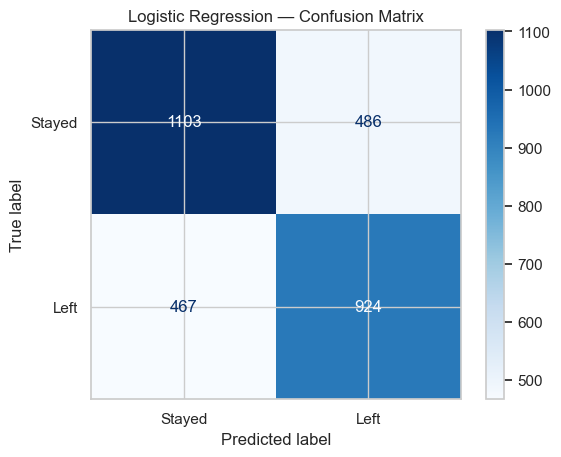


Top Feature Influences:
                  Feature  Coefficient
10           Remote Work    -1.454278
9              Job Level    -1.000937
6               Overtime     0.298784
3   Number of Promotions    -0.198408
8      Work-Life Balance     0.196372
7       Job Satisfaction     0.144349
5               Job Role    -0.041961
2       Years at Company    -0.011797


In [15]:
# ── Cell 15 · Logistic Regression ─────────────────────

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("── Logistic Regression Results ──")
print(classification_report(y_test, y_pred_lr,
      target_names=['Stayed', 'Left']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(cm, display_labels=['Stayed', 'Left'])
disp.plot(cmap='Blues')
plt.title('Logistic Regression — Confusion Matrix')
plt.show()

# Top feature coefficients
coef_df = pd.DataFrame({'Feature': X.columns,
                          'Coefficient': lr.coef_[0]})
coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=False).index)
print("\nTop Feature Influences:\n", coef_df.head(8))

── Decision Tree Results ──
              precision    recall  f1-score   support

      Stayed       0.77      0.50      0.61      1589
        Left       0.59      0.83      0.69      1391

    accuracy                           0.65      2980
   macro avg       0.68      0.66      0.65      2980
weighted avg       0.69      0.65      0.65      2980


Decision Tree Rules (depth=3):

|--- Job Level <= 1.50
|   |--- Remote Work <= 0.50
|   |   |--- Job Level <= 0.50
|   |   |   |--- class: 1
|   |   |--- Job Level >  0.50
|   |   |   |--- class: 1
|   |--- Remote Work >  0.50
|   |   |--- Job Level <= 0.50
|   |   |   |--- class: 0
|   |   |--- Job Level >  0.50
|   |   |   |--- class: 0
|--- Job Level >  1.50
|   |--- Remote Work <= 0.50
|   |   |--- Work-Life Balance <= 0.50
|   |   |   |--- class: 0
|   |   |--- Work-Life Balance >  0.50
|   |   |   |--- class: 0
|   |--- Remote Work >  0.50
|   |   |--- Work-Life Balance <= 2.50
|   |   |   |--- class: 0
|   |   |--- Work-Life Bala

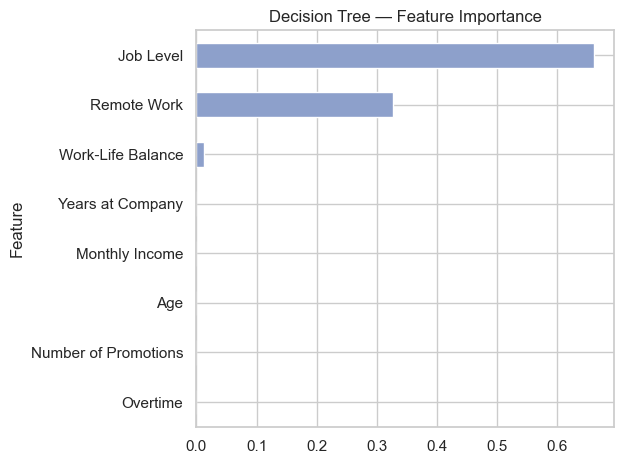

In [16]:
# ── Cell 16 · Decision Tree ───────────────────────────

dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("── Decision Tree Results ──")
print(classification_report(y_test, y_pred_dt,
      target_names=['Stayed', 'Left']))

# Print tree rules (easy to read)
tree_rules = export_text(dt, feature_names=list(X.columns))
print("\nDecision Tree Rules (depth=3):\n")
print(tree_rules)

# Feature importances
imp_df = pd.DataFrame({'Feature': X.columns,
                        'Importance': dt.feature_importances_})
imp_df = imp_df.sort_values('Importance', ascending=False)

imp_df.head(8).plot(kind='barh', x='Feature', y='Importance',
                    color='#8da0cb', legend=False)
plt.title('Decision Tree — Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [17]:
overall_rate = df['Attrition Flag'].mean() * 100
ot_rate      = df[df['Overtime'] == 'Yes']['Attrition Flag'].mean() * 100
no_ot        = df[df['Overtime'] == 'No']['Attrition Flag'].mean() * 100
low_sal      = df[df['Salary Group'] == 'Low']['Attrition Flag'].mean() * 100
top_role     = df.groupby('Job Role')['Attrition Flag'].mean().idxmax()

print("═══════════════════════════════════════════")
print("     EMPLOYEE ATTRITION — KEY FINDINGS     ")
print("═══════════════════════════════════════════")
print(f"  Overall Attrition Rate : {overall_rate:.1f}%")
print(f"  With Overtime          : {ot_rate:.1f}%")
print(f"  Without Overtime       : {no_ot:.1f}%")
print(f"  Low Salary Band        : {low_sal:.1f}% attrition")
print(f"  Highest Risk Job Role  : {top_role}")
print("═══════════════════════════════════════════")
print("\nHR RECOMMENDATIONS:")
print("  1. Limit overtime for entry-level staff")
print("  2. Review salary bands — Low band is high risk")
print("  3. Run quarterly satisfaction surveys")
print("  4. Expand remote work options to improve retention")
print("  5. Create promotion pipelines for 3–5 yr employees")

═══════════════════════════════════════════
     EMPLOYEE ATTRITION — KEY FINDINGS     
═══════════════════════════════════════════
  Overall Attrition Rate : 47.2%
  With Overtime          : 51.3%
  Without Overtime       : 45.2%
  Low Salary Band        : 48.7% attrition
  Highest Risk Job Role  : Education
═══════════════════════════════════════════

HR RECOMMENDATIONS:
  1. Limit overtime for entry-level staff
  2. Review salary bands — Low band is high risk
  3. Run quarterly satisfaction surveys
  4. Expand remote work options to improve retention
  5. Create promotion pipelines for 3–5 yr employees


In [22]:
# rename columns (remove spaces and hyphens)
df.columns = df.columns.str.replace(" ", "_")
df.columns = df.columns.str.replace("-", "_")

# view updated column names
df.columns

Index(['Age', 'Gender', 'Years_at_Company', 'Job_Role', 'Monthly_Income',
       'Work_Life_Balance', 'Job_Satisfaction', 'Performance_Rating',
       'Number_of_Promotions', 'Overtime', 'Distance_from_Home',
       'Education_Level', 'Marital_Status', 'Number_of_Dependents',
       'Job_Level', 'Company_Size', 'Company_Tenure', 'Remote_Work',
       'Leadership_Opportunities', 'Innovation_Opportunities',
       'Company_Reputation', 'Employee_Recognition', 'Attrition',
       'Salary_Group', 'Experience_Group', 'Age_Group', 'Attrition_Flag'],
      dtype='object')

In [23]:
!pip install mysql-connector-python sqlalchemy pymysql

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Pratham\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [24]:
from sqlalchemy import create_engine

username = "root"
password = "7272"
host = "localhost"
port = "3306"
database = "hr_analytics"

engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")

df.to_sql(
    name="employee_attrition",
    con=engine,
    if_exists="replace",
    index=False
)

print("Data uploaded successfully!")

Data uploaded successfully!
